# 1. Setup & Load Data

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
# Load CSV
df = pd.read_csv('temp_data/classified_articles_all_media_houses.csv')

In [42]:
# Preview data
df.head()

,file_name,article_index,article_id,title,date_published,author,source,source_url,classification,raw_model_response,Unnamed: 10
0,news_diggers_articles_full2.json,1,302899,Bill 7 will return to Parley in upcoming sessi...,2025-09-09T08:06:34,24604,news diggers,https://diggers.news/local/2025/09/09/bill-7-w...,No,No,NaN
1,news_diggers_articles_full2.json,2,302942,Ex-Chipolopolo gaffer hails ‘return of footbal...,2025-09-09T07:53:54,22148,news diggers,https://diggers.news/goal-diggers/2025/09/09/e...,No,No,NaN
2,news_diggers_articles_full2.json,3,302783,We don’t know tricks to kill opposition – UPND,2025-09-09T07:50:09,13921,news diggers,https://diggers.news/local/2025/09/09/we-dont-...,No,No,NaN
3,news_diggers_articles_full2.json,4,302931,Foreigners encouraging illegal mining – Kabuswe,2025-09-09T07:46:20,24604,news diggers,https://diggers.news/business/2025/09/09/forei...,No,No,NaN
4,news_diggers_articles_full2.json,5,302646,HH is the worst President Zambia has ever had ...,2025-09-09T07:44:24,3666,news diggers,https://diggers.news/local/2025/09/09/hh-is-th...,No,No,NaN


In [43]:
df.columns

Index(['file_name', 'article_index', 'article_id', 'title', 'date_published',
       'author', 'source', 'source_url', 'classification',
       'raw_model_response', 'Unnamed: 10'],
      dtype='object')

# 2. Data Cleaning 
Ensure the classification is consistent

In [45]:
# Standardize classification(yes/N0)
df['classification'] = df['classification'].str.strip().str.upper()

# Convert date
df['date_published'] = pd.to_datetime(df['date_published'], errors='coerce')

# Extract year
df['year'] = df['date_published'].dt.year

# 3. Frequency of Research-Based Articles
## Overall frequency

In [46]:
freq = df['classification'].value_counts()
print(freq)

classification
NO     14966
YES      174
Name: count, dtype: int64


In [47]:
# Percentage
percentage = df['classification'].value_counts(normalize=True) * 100
print(percentage)

classification
NO     98.850727
YES     1.149273
Name: proportion, dtype: float64


## Visualization

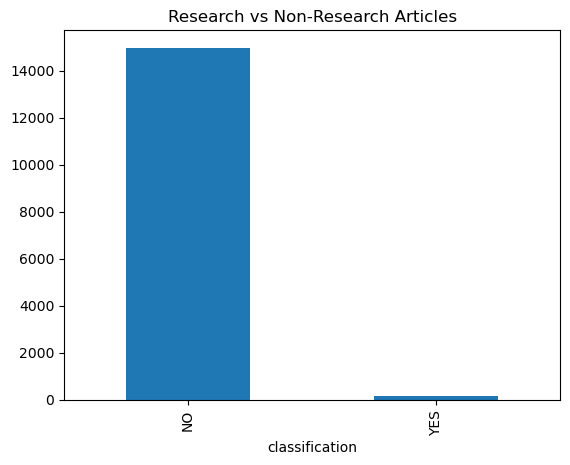

In [48]:
freq.plot(kind='bar', title='Research vs Non-Research Articles')
plt.show()

# 4. Trend Over the Years

In [49]:
trend = df.groupby(['year', 'classification']).size().unstack(fill_value=0)

print(trend)

classification    NO  YES
year                     
2019.0          1244   92
2023.0           872    2
2024.0          7653   43
2025.0          5141   37


## Plot trend

<function matplotlib.pyplot.show(close=None, block=None)>

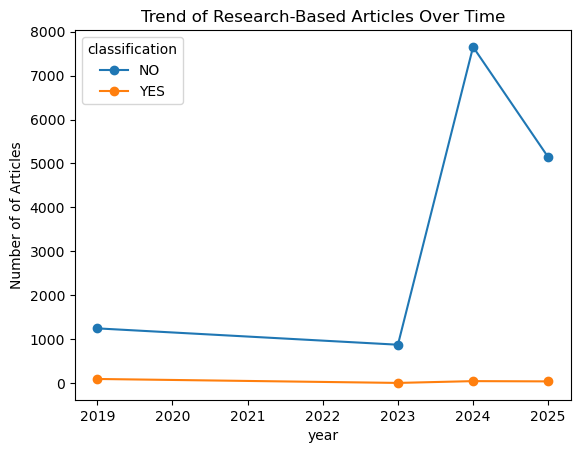

In [50]:
trend.plot(marker='o', title='Trend of Research-Based Articles Over Time')
plt.ylabel('Number of of Articles')
plt.show

## Percentage trend

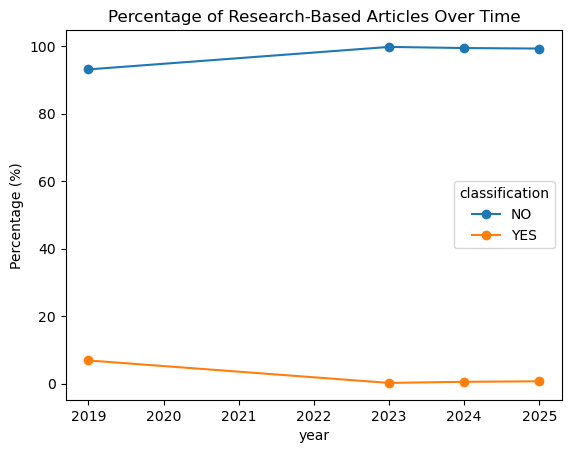

In [51]:
trend_percent = trend.div(trend.sum(axis=1), axis=0)* 100

trend_percent.plot(marker='o', title='Percentage of Research-Based Articles Over Time')
plt.ylabel('Percentage (%)')
plt.show()

# 5. Insights by Media House

In [52]:
by_source = df.groupby(['source', 'classification']).size().unstack(fill_value=0)
print(by_source)

classification     NO  YES
source                    
lusaka times     1247   92
news diggers    13719   82


In [53]:
df.columns.tolist()

['file_name',
 'article_index',
 'article_id',
 'title',
 'date_published',
 'author',
 'source',
 'source_url',
 'classification',
 'raw_model_response',
 'Unnamed: 10',
 'year']

## Percentage per source

In [54]:
by_source_percent = by_source.div(by_source.sum(axis=1), axis=0) * 100

print(by_source_percent)

classification         NO       YES
source                             
lusaka times    93.129201  6.870799
news diggers    99.405840  0.594160


# 6. Monthly Trends

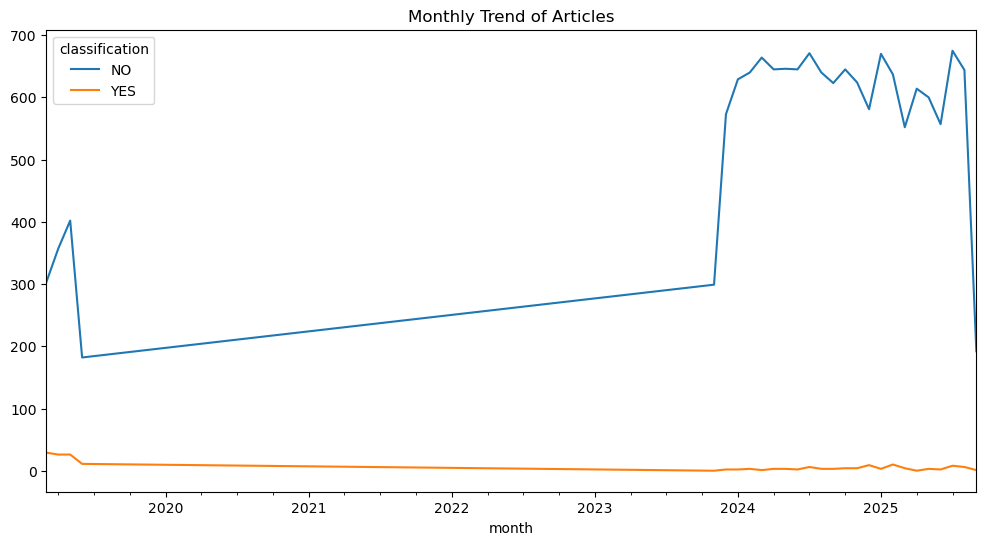

In [55]:
df['month'] = df['date_published'].dt.to_period('M')

monthly_trend = df.groupby(['month', 'classification']).size().unstack(fill_value=0)

monthly_trend.plot(figsize=(12,6), title='Monthly Trend of Articles')
plt.show()

# 7. Additional Insights

In [56]:
from collections import Counter
import re

research_articles = df[df['classification'] == 'YES']

text = " " . join(research_articles['title'].dropna())

words = re.findall(r'\w+', text.lower())
common_words = Counter(words).most_common(20)

print(common_words)

[('of', 61), ('to', 48), ('in', 44), ('the', 43), ('zambia', 42), ('s', 30), ('and', 26), ('for', 24), ('a', 22), ('zambian', 14), ('is', 13), ('from', 12), ('on', 12), ('by', 11), ('are', 10), ('at', 10), ('part', 9), ('we', 9), ('africa', 9), ('ag', 8)]
